> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib pandas tabulate


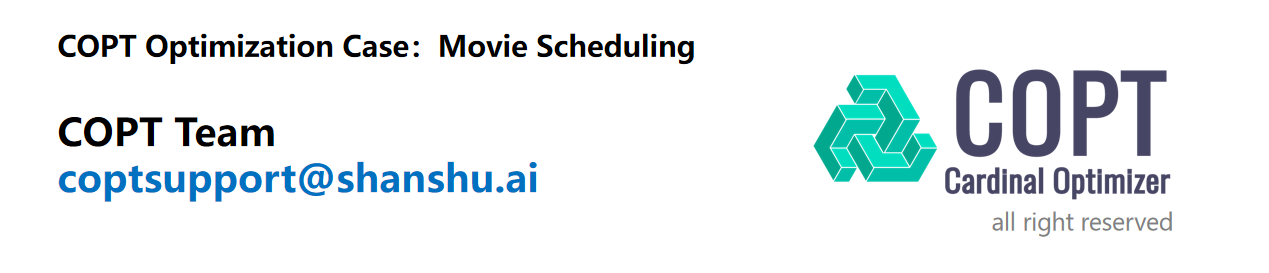

# Movie Scheduling Optimization Problem Code Implementation
## Steps to Model and Solve Movie Scheduling Optimization Problem Using COPT

1. **Import the COPT-Python interface library** `coptpy`

2. **Import and preprocess data**
   - Import theater screening room data (capacity, supported versions, screening costs, etc.)
   - Import movie data (duration, rating, genre, language, allowed versions, revenue sharing ratio, etc.)
   - Add other parameter data (basic unit cost of auditorium, fixed cost, minimum interval between screenings, price increase coefficient during prime time, etc.)

3. **Preprocess data**
   - Auditorium data and movie data preprocessing
   - Construct auxiliary sets (e.g., `allowed_versions`, `room_supports`, `genre_to_movies`, `valid_start_time`, etc.)

4. **Create the COPT solver environment and model**

5. **Build the model: sequentially add the three key components**
   - **Decision variables**: define the scheduling variable $x_{r,m,v,t}$, indicating whether movie $m$ is scheduled in room $r$ at time $t$ with version $v$ (0/1 variable). Variables are pre-filtered to reduce problem size;
   - **Objective function**: calculate revenue and cost according to requirements, maximizing the theater's net profit within a single business cycle;
   - **Constraints**:
     - Non-overlapping time constraint (including cleaning and maintenance interval);
     - Time-window cumulative runtime constraint;
     - Genre screening frequency constraint;
     - Version total runtime constraint.

6. **Solve**

7. **View and analyze results**: print the schedule, **verify every constraint** against the solution, and plot the **Gantt chart** and cumulative profit curve

## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT

from collections import defaultdict
import math
import pandas as pd
from tabulate import tabulate

## Add Model Data

In [6]:
movie_data = [{'id': '436270', 'genres': 'Action,Fantasy,Science Fiction', 'original_language': 'English', 'version': '2D', 'runtime': '125', 'rating': '6.092', 'basic_price': '41'},
              {'id': '882598', 'genres': 'Horror,Mystery,Thriller', 'original_language': 'English', 'version': '2D', 'runtime': '116', 'rating': '6.715', 'basic_price': '43'},
              {'id': '505642', 'genres': 'Action,Adventure,Science Fiction', 'original_language': 'English', 'version': '2D', 'runtime': '161', 'rating': '6.473', 'basic_price': '45'},
              {'id': '966220', 'genres': 'Drama,Action,War', 'original_language': 'Ukrainian', 'version': '2D', 'runtime': '120', 'rating': '7.393', 'basic_price': '46'},
              {'id': '663712', 'genres': 'Horror,Thriller', 'original_language': 'English', 'version': '2D', 'runtime': '138', 'rating': '6.461', 'basic_price': '44'},
              {'id': '829280', 'genres': 'Mystery,Adventure,Crime', 'original_language': 'English', 'version': '2D', 'runtime': '129', 'rating': '7.373', 'basic_price': '42'},
              {'id': '676701', 'genres': 'Adventure,Animation,Comedy', 'original_language': 'Spanish', 'version': '2D', 'runtime': '89', 'rating': '7.375', 'basic_price': '48'},
              {'id': '675054', 'genres': 'Horror,Action,Comedy', 'original_language': 'Spanish', 'version': '2D', 'runtime': '93', 'rating': '6.333', 'basic_price': '43'},
              {'id': '979924', 'genres': 'Thriller', 'original_language': 'English', 'version': '2D', 'runtime': '104', 'rating': '6.066', 'basic_price': '42'},
              {'id': '235672', 'genres': 'Adventure,Action,Science Fiction', 'original_language': 'English', 'version': '2D', 'runtime': '134', 'rating': '5.908', 'basic_price': '41'},
              {'id': '672392', 'genres': 'Action,Adventure,Adventure,Thriller', 'original_language': 'English', 'version': '2D', 'runtime': '170', 'rating': '6.872', 'basic_price': '42'},
              {'id': '721193', 'genres': 'Action,Drama', 'original_language': 'English', 'version': '2D,3D,IMAX', 'runtime': '156', 'rating': '7.864', 'basic_price': '48'},
              {'id': '812924', 'genres': 'Animation,Fantasy,Adventure,Action', 'original_language': 'Mandarin', 'version': '2D,3D,IMAX', 'runtime': '144', 'rating': '8.25', 'basic_price': '45'},
              {'id': '192801', 'genres': 'Family,Comedy,Adventure,Animation,Science Fiction', 'original_language': 'English', 'version': '2D', 'runtime': '98', 'rating': '6.941', 'basic_price': '43'},
              {'id': '723921', 'genres': 'Comedy,Suspense,Action', 'original_language': 'Mandarin,English', 'version': '2D', 'runtime': '136', 'rating': '5.5', 'basic_price': '46'},
              {'id': '402101', 'genres': 'Family,Comedy,Adventure,Science Fiction', 'original_language': 'English', 'version': '2D', 'runtime': '104', 'rating': '7.1', 'basic_price': '40'},
              {'id': '837808', 'genres': 'Fantasy,Family,Action', 'original_language': 'English', 'version': '2D', 'runtime': '126', 'rating': '7.9', 'basic_price': '46'},
              {'id': '180219', 'genres': 'Drama,Crime', 'original_language': 'Mandarin,Shanghainese', 'version': '2D', 'runtime': '96', 'rating': '7.737', 'basic_price': '40'},
              {'id': '290003', 'genres': 'Action,Adventure,Drama', 'original_language': 'English,Mandarin', 'version': '2D', 'runtime': '94', 'rating': '7.207', 'basic_price': '47'}]

cinema_data = [{'room': 'R01', 'capacity': '130', '2D': '1', '3D': '1', 'IMAX': '0'},
               {'room': 'R02', 'capacity': '90', '2D': '1', '3D': '1', 'IMAX': '1'},
               {'room': 'R03', 'capacity': '100', '2D': '1', '3D': '0', 'IMAX': '0'},
               {'room': 'R04', 'capacity': '150', '2D': '1', '3D': '1', 'IMAX': '1'},
               {'room': 'R05', 'capacity': '100', '2D': '1', '3D': '0', 'IMAX': '0'},
               {'room': 'R06', 'capacity': '100', '2D': '1', '3D': '1', 'IMAX': '0'},
               {'room': 'R07', 'capacity': '120', '2D': '1', '3D': '1', 'IMAX': '1'},
               {'room': 'R08', 'capacity': '100', '2D': '1', '3D': '1', 'IMAX': '0'}]

basic_cost = 2.42
fixed_cost = 90
min_gap = 15
prime_coeff = 1.30
genre_bounds = {
    "Animation":(1, 5),
    "Horror": (0, 3),
    "Action": (2, 6),
    "Drama": (1, 6),
}
max_runtime = {"3D": 1200, "IMAX": 1500}

## Preprocess Data

Preprocessing only **reads** `movie_data` / `cinema_data` and writes its results into new
dictionaries, rather than modifying the raw data in place. This keeps every cell safe to
re-run: otherwise a second execution would round an already-rounded runtime again, or try
to `split()` a list that has already been split.

In [8]:
# ---------- Version coefficients ----------
VERSION_PRICE_COEFF = {"2D": 1.00, "3D": 1.20, "IMAX": 1.23}   # ticket price coefficient
VERSION_COST_COEFF = {"2D": 1.00, "3D": 1.10, "IMAX": 1.15}    # screening cost coefficient

# ---------- Time axis ----------
OPEN_MIN, CLOSE_MIN, STEP = 0, 1020, 15   # 0 = 10:00, 1020 = 03:00 next day, 15-min grid


def round_runtime(minutes, unit=30):
    """Round a runtime up to a multiple of `unit` minutes: 125 -> 150, and 120 stays 120."""
    return math.ceil(minutes / unit) * unit


# ---------- Auditorium data processing ----------
capacity = {r["room"]: int(r["capacity"]) for r in cinema_data}
# Versions each auditorium supports
room_supports = {r["room"]: [v for v in ("2D", "3D", "IMAX") if int(r[v])]
                 for r in cinema_data}
# Screening cost = version_coeff * capacity * basic_cost + fixed_cost
cost = {room: {v: VERSION_COST_COEFF[v] * capacity[room] * basic_cost + fixed_cost
               for v in supported}
        for room, supported in room_supports.items()}

# ---------- Movie data processing ----------
genres = {m["id"]: m["genres"].split(",") for m in movie_data}
languages = {m["id"]: m["original_language"].split(",") for m in movie_data}
allowed_versions = {m["id"]: m["version"].split(",") for m in movie_data}
runtime = {m["id"]: round_runtime(int(m["runtime"])) for m in movie_data}
rating = {m["id"]: float(m["rating"]) for m in movie_data}
basic_price = {m["id"]: int(m["basic_price"]) for m in movie_data}
# Ticket price: 3D is 1.2x the 2D price, IMAX is 1.23x
price = {mid: {v: VERSION_PRICE_COEFF[v] * basic_price[mid] for v in vs}
         for mid, vs in allowed_versions.items()}
# Sharing rate: a film whose original language includes Mandarin counts as domestic
sharing_rate = {mid: 0.43 if "Mandarin" in langs else 0.51
                for mid, langs in languages.items()}

## Generate Sets

In [10]:
# ---------- Basic sets ----------
rooms = [r["room"] for r in cinema_data]
movies = [m["id"] for m in movie_data]
versions = ["2D", "3D", "IMAX"]

# Prime time 18:00-21:00, treated as a closed interval: screenings starting at
# either 18:00 or 21:00 are charged the increased ticket price.
prime_time = list(range(480, 660 + 1, STEP))

# ---------- Mapping sets ----------
genre_to_movies = defaultdict(list)
for mid in movies:
    for g in genres[mid]:
        genre_to_movies[g].append(mid)

version_to_movies = defaultdict(list)
for mid in movies:
    for v in allowed_versions[mid]:
        version_to_movies[v].append(mid)

# attendance = floor(auditorium capacity * rating / 10)
attendance = {r: {m: math.floor(capacity[r] * rating[m] / 10) for m in movies}
              for r in rooms}


# ---------- Valid start times ----------
def get_valid_time(movie_genres, movie_runtime,
                   open_time=OPEN_MIN, close_time=CLOSE_MIN, step=STEP):
    """
    Return the set of valid start times for a movie, given its genres and runtime.
    - movie_genres : list[str] genres of the movie
    - movie_runtime: int runtime already rounded up to a multiple of 30 minutes
    - open_time    : int start of business hours (default 0, i.e. 10:00)
    - close_time   : int end of business hours (default 1020, i.e. 03:00 next day)
    - step         : int time step (default 15 minutes)
    """
    # By default: within business hours, and finishing before closing time
    earliest, latest = open_time, close_time - movie_runtime

    # Animation / Family: daytime only (must start by 19:00)
    if any(g in movie_genres for g in ["Animation", "Family"]):
        latest = min(latest, 540)

    # Horror / Thriller: evening only (cannot start before 21:00)
    if any(g in movie_genres for g in ["Horror", "Thriller"]):
        earliest = max(earliest, 660)

    if latest < earliest:
        return []
    return list(range(earliest, latest + 1, step))


valid_start_time = {mid: get_valid_time(genres[mid], runtime[mid]) for mid in movies}

## Create the COPT Environment and COPT Model

In [12]:
env = cp.Envr()
model = env.createModel("Movie_Schedule")

Cardinal Optimizer v8.0.6. Build date Aug  7 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add three core components of COPT Model

### Add Decision Variables
$$
x_{r,m,v,t} =
\begin{cases}
1,\ \text{if movie $m$ in version $v$ starts at time $t$ in auditorium $r$} \\
0,\ \text{otherwise}
\end{cases}
$$

- The allowed screening time of a movie must not exceed business hours and must satisfy genre-specific restrictions. This can be ensured by traversing valid times using the $valid\_start\_time$ mapping;  
- The versions supported by an auditorium must match the movie’s available versions. Therefore, we only traverse versions that are present in both $allowed\_versions$ and $room\_supports$;  

These constraints can be implemented during variable pre-screening and do not need to be explicitly added to the model.  

In [14]:
x = {}
for r in rooms:
    for m in movies:
        for v in set(allowed_versions[m]) & set(room_supports[r]):
            for t in valid_start_time[m]:
                x[r, m, v, t] = model.addVar(vtype=COPT.BINARY, name=f"x({r},{m},{v},{t})")

print(f"{len(x)} decision variables generated after pre-filtering")

7222 decision variables generated after pre-filtering


### Set Objective Function
Maximize the net profit within a single business cycle: 
$$
\text{Net profit in one business cycle} = \sum_{\text{all screenings}} \big[ \text{Ticket revenue} \times (1 - \text{Producer sharing rate}) - \text{Screening cost} \big]
$$
$$
\max_{x_{r,m,v,t}}
\sum_{r} \sum_{m} \sum_{v} \sum_{t}
x_{r,m,v,t} \cdot \Big( \big(attendance[r][m] \cdot price[m][v] \cdot prime\_coeff \big) \cdot (1 - sharing\_rate[m]) - cost[r][v] \Big)
$$


In [16]:
model.setObjective(
    cp.quicksum(
        x[r, m, v, t] * (
            attendance[r][m] * price[m][v] * (prime_coeff if t in prime_time else 1.0) * (1-sharing_rate[m]) - cost[r][v]
        )
        for (r, m, v, t) in x
    ),
    sense=COPT.MAXIMIZE
)

### Add constraints

1. **Non-overlapping time constraint (including cleaning and maintenance interval):**

   Each auditorium can only screen one movie at a time, and there must be at least
   $min\\_gap$ minutes between consecutive screenings.

   The most direct formulation writes one $x_1 + x_2 \\leq 1$ for **every pair** of
   conflicting variables. That produces a number of constraints quadratic in the number of
   variables (about 1.08 million here), which is slow to build and gives a weak LP relaxation.

   Another way to look at it: if the cleaning gap is folded into the occupied time, a
   screening occupies its auditorium over the interval
   $[t,\\ t + runtime[m] + min\\_gap)$, and "no two screenings conflict" is equivalent to
   "at most one screening occupies the auditorium at any instant". So the constraints can be
   written **per time point** instead:

$$
\forall r \in rooms,\ \forall \tau \in \{0, 15, \ldots, 1020\}:
$$
$$
\sum_{m}\sum_{v}\sum_{\substack{t \in valid\_start\_time[m] \\ t \le \tau < t + runtime[m] + min\_gap}}
x_{r,m,v,t} \leq 1
$$

   Since all start times, runtimes and cleaning gaps are multiples of 15 minutes, it is
   enough to enumerate $\\tau$ on the 15-minute grid. For binary $x$ the two formulations
   have **exactly the same feasible region**, but the constraint count drops from about
   1.08 million to $8 \\times 69 = 552$. Each constraint also rules out every conflicting
   combination at that instant in one shot, so the LP relaxation is tighter and the model
   solves substantially faster.

In [19]:
# One constraint per time point: at most one screening occupies the auditorium
# Constraint count = auditoriums x time points, far fewer than the pairwise version
n_conflict = 0
for r in rooms:
    for tau in range(OPEN_MIN, CLOSE_MIN + 1, STEP):
        # All screenings still occupying auditorium r at instant tau
        # (the occupied interval already includes the cleaning gap)
        occupying = [
            x[r, m, v, t]
            for m in movies
            for v in set(allowed_versions[m]) & set(room_supports[r])
            for t in valid_start_time[m]
            if t <= tau < t + runtime[m] + min_gap
        ]
        if len(occupying) >= 2:
            model.addConstr(cp.quicksum(occupying) <= 1, name=f"no_overlap_{r}_{tau}")
            n_conflict += 1

print(f"{n_conflict} non-overlapping time constraints added")

552 non-overlapping time constraints added


2. **Time-window cumulative runtime constraint:**

Each auditorium $r$ can screen at most 7 hours of movies within any 9-hour window. Since
movie runtimes and cleaning gaps are multiples of 15 minutes, the sliding window can be
discretized by 15-minute intervals.

The time a screening $(m,v,t)$ contributes to the window
$[window\_left,\\ window\_right]$ is the **overlap length** of the two intervals:

$$
overlap(m,t) = \max\Big(0,\ \min\big(t + runtime[m],\ window\_right\big) - \max\big(t,\ window\_left\big)\Big)
$$

$$
\forall r \in rooms,\ \forall [window\_left,\ window\_right]:\qquad
\sum_{m} \sum_{v} \sum_{t} overlap(m,t) \cdot x_{r,m,v,t} \leq 7 \times 60
$$

In [21]:
total_hour = 9   # sliding window length
run_hour = 7     # maximum cumulative runtime within a window


def overlap(start, end, window_left, window_right):
    """Overlap length of two intervals (0 when they do not overlap)."""
    return max(0, min(end, window_right) - max(start, window_left))


for r in rooms:
    for window_left in range(OPEN_MIN, CLOSE_MIN - total_hour * 60 + 1, STEP):
        window_right = window_left + total_hour * 60
        terms = []
        for m in movies:
            for v in set(allowed_versions[m]) & set(room_supports[r]):
                for t in valid_start_time[m]:
                    d = overlap(t, t + runtime[m], window_left, window_right)
                    if d > 0:               # skip zero coefficients to reduce nonzeros
                        terms.append(d * x[r, m, v, t])
        model.addConstr(
            cp.quicksum(terms) <= run_hour * 60,
            name=f"time_window_[{window_left},{window_right}]_in_{r}_constr"
        )

3. **Genre screening frequency constraint:**  
   For each specified genre $genre$, the total number of screenings must satisfy the given lower and upper bounds:  

$$
\forall r \in rooms,\ \forall m \in genre\_to\_movies[genre],\ \forall v \in versions,\ \forall t \in valid\_start\_time[m]:
$$
$$
genre\_bounds[genre]_{min} \leq
\sum_{r} \sum_{m} \sum_{v} \sum_{t} x_{r,m,v,t}
\leq genre\_bounds[genre]_{max}
$$


In [23]:
for genre, (lower, upper) in genre_bounds.items():
    play_times = cp.quicksum(
        x[r, m, v, t]
        for r in rooms
        for m in genre_to_movies[genre]
        for v in set(allowed_versions[m]) & set(room_supports[r])
        for t in valid_start_time[m]
    )
    if lower > 0:
        model.addConstr(play_times >= lower, name=f"min_play_{genre}")
    model.addConstr(play_times <= upper, name=f"max_play_{genre}")

4. **Version total runtime constraint:**  
    The cinema has upper bounds on the total screening time for 3D and IMAX movies:  
$$
\forall r \in rooms,\ \forall m \in movies,\ \forall t \in valid\_start\_time[m],
$$
$$
\sum_{r} \sum_{m} \sum_{t} runtime[m] \cdot x_{r,m,3D,t} \leq max\_runtime[3D]
$$
$$
\sum_{r} \sum_{m} \sum_{t} runtime[m] \cdot x_{r,m,IMAX,t} \leq max\_runtime[IMAX]
$$


In [25]:
for v, upper in max_runtime.items():
    model.addConstr(
        cp.quicksum(
            runtime[m] * x[r, m, v, t]
            for r in rooms if v in room_supports[r]
            for m in version_to_movies[v]
            for t in valid_start_time[m]
        ) <= upper,
        name=f"max_runtime_{v}_constr"
    )

## Solve

In [27]:
# The default relative gap is 1e-4 and can be tightened if needed
model.setParam(COPT.Param.RelGap, 1e-4)
model.setParam(COPT.Param.TimeLimit, 600)

model.solve()

Setting parameter 'RelGap' to 0.0001
Setting parameter 'TimeLimit' to 600
Model fingerprint: f67f03da

Using Cardinal Optimizer v8.0.6 on macOS (15.7.3 Build 24G419 - arm64)
The CPU model is Apple M4
Hardware has 10 physical cores and 10 logical cores. Using instruction set ARMV8 (30)
Maximizing a MIP problem

The original problem has:
    825 rows, 7222 columns and 262821 non-zero elements
    7222 binaries

Starting the MIP solver with 10 threads and 32 tasks

Presolving the problem

The presolved problem has:
    567 rows, 1866 columns and 66154 non-zero elements
    1866 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,2e+02]
    Range of rhs coefficients:       [1e+00,4e+02]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [8e+02,5e+03]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  3.264380e+06           

## Retrieve Results

When extracting the schedule we **keep the raw minute values** `start` / `end` and only
format them as `HH:MM` for display. The Gantt chart below shows.

In [29]:
def minutes_to_time(t):
    """Convert minutes (0 = 10:00) to an HH:MM string; use modulo, not floor division."""
    hours, minutes = divmod(600 + t, 60)
    return f"{hours % 24:02d}:{minutes:02d}"


def get_schedule(model, x):
    """Extract the schedule from the solution, with per-screening revenue, cost and profit."""
    if model.status == COPT.INFEASIBLE:
        print("model is infeasible")
        model.computeIIS()
        model.writeIIS("infeasible.iis")
        return None
    if model.hasmipsol == 0:
        print(f"no feasible solution found, status = {model.status}")
        return None
    if model.status != COPT.OPTIMAL:
        print(f"[warn] optimality not proven, current gap = {model.bestgap:.4%}")

    plan = []
    for (r, m, v, t), var in x.items():
        if var.x < 0.5:
            continue
        ticket = price[m][v] * (prime_coeff if t in prime_time else 1.0)
        revenue = attendance[r][m] * ticket * (1 - sharing_rate[m])
        plan.append({
            "room": r,
            "start": t,
            "end": t + runtime[m],
            "start_hhmm": minutes_to_time(t),
            "end_hhmm": minutes_to_time(t + runtime[m]),
            "id": m,
            "version": v,
            "runtime": runtime[m],
            "attendance": attendance[r][m],
            "load_factor": attendance[r][m] / capacity[r],
            "is_prime": t in prime_time,
            "revenue": revenue,
            "cost": cost[r][v],
            "net": revenue - cost[r][v],
        })
    return sorted(plan, key=lambda d: (d["room"], d["start"]))


results = get_schedule(model, x)
schedule_df = pd.DataFrame(results)

print(tabulate(
    schedule_df[["room", "start_hhmm", "end_hhmm", "id", "version",
                 "attendance", "load_factor", "is_prime", "net"]],
    headers=["Auditorium", "Start", "End", "Movie", "Version",
             "Attendance", "Load", "Prime", "Net (CNY)"],
    showindex=False, stralign="center", numalign="center",
    floatfmt=("", "", "", "", "", ".0f", ".1%", "", ",.1f"),
))

 Auditorium    Start    End    Movie    Version    Attendance    Load    Prime    Net (CNY)
------------  -------  -----  -------  ---------  ------------  ------  -------  -----------
    R01        10:00   12:00  402101      2D           92       70.8%    False     1,398.6
    R01        12:15   14:45  812924      3D          107       82.3%    False     2,857.4
    R01        15:45   17:45  180219      2D          100       76.9%    False     1,875.4
    R01        18:30   20:30  180219      2D          100       76.9%    True      2,559.4
    R01        20:45   23:45  721193      3D          102       78.5%    True      3,306.4
    R01        01:00   03:00  882598      2D           87       66.9%    False     1,428.5
    R02        10:00   12:00  402101      2D           63       70.0%    False      927.0
    R02        12:15   14:45  829280      2D           66       73.3%    False     1,050.5
    R02        15:30   17:30  402101      2D           63       70.0%    False      927.

## Verify the Solution

A solver reporting "optimal" only means the **model** was solved correctly — it says nothing
about whether the **model was written correctly**. Below, every operating rule is recomputed
from the schedule that was returned. This confirms the plan is feasible and, just as usefully,
shows **which constraints are tight** — often more informative than the objective value itself.

In [31]:
def check_solution(plan):
    """Re-check the schedule against every operating rule, flagging binding constraints."""
    total_net = sum(p["net"] for p in plan)

    print("=" * 72)
    print("SOLUTION SUMMARY")
    print("=" * 72)
    print(f"Net profit               : CNY {total_net:>12,.2f}   "
          f"(model objective CNY {model.objval:,.2f})")
    print(f"Ticket revenue (post-share): CNY {sum(p['revenue'] for p in plan):>10,.2f}")
    print(f"Screening cost           : CNY {sum(p['cost'] for p in plan):>12,.2f}")
    n_prime = sum(p["is_prime"] for p in plan)
    net_prime = sum(p["net"] for p in plan if p["is_prime"])
    print(f"Total screenings         : {len(plan):>16d}   "
          f"of which {n_prime} in prime time, contributing "
          f"{net_prime / total_net:.0%} of net profit")

    print("\n" + "-" * 72)
    print("(1) Business hours / same-auditorium overlap / cleaning gap")
    print("-" * 72)
    feasible = True
    for r in rooms:
        shows = sorted([p for p in plan if p["room"] == r], key=lambda d: d["start"])
        for p in shows:
            if p["start"] < OPEN_MIN or p["end"] > CLOSE_MIN:
                print(f"  [X] {r} {p['start_hhmm']}-{p['end_hhmm']} outside business hours")
                feasible = False
        for a, b in zip(shows, shows[1:]):
            if b["start"] - a["end"] < min_gap:
                print(f"  [X] {r} {a['end_hhmm']} -> {b['start_hhmm']} cleaning gap too short")
                feasible = False
    if feasible:
        print("  [OK] all satisfied")

    print("\n" + "-" * 72)
    print("(2) At most 7 screening hours in any 9-hour window")
    print("-" * 72)
    for r in rooms:
        shows = [p for p in plan if p["room"] == r]
        peak = max(
            sum(overlap(p["start"], p["end"], wl, wl + total_hour * 60) for p in shows)
            for wl in range(OPEN_MIN, CLOSE_MIN - total_hour * 60 + 1, STEP)
        )
        used = sum(p["runtime"] for p in shows)
        print(f"  {r}: window peak {peak / 60:>4.1f}h / {run_hour}.0h"
              f"{'  <= tight' if peak == run_hour * 60 else '':<11}"
              f"  full day {used / 60:>4.1f}h (utilisation {used / CLOSE_MIN:>4.0%})")

    print("\n" + "-" * 72)
    print("(3) Genre screening frequency bounds")
    print("-" * 72)
    for g, (lower, upper) in genre_bounds.items():
        n = sum(1 for p in plan if g in genres[p["id"]])
        tag = "<= at upper bound (tight)" if n == upper else \
              ("<= at lower bound (tight)" if n == lower else "")
        label = "screening" if n == 1 else "screenings"
        print(f"  {g:<10}: {n:>2d} {label:<10} required [{lower}, {upper}]   {tag}")

    print("\n" + "-" * 72)
    print("(4) 3D / IMAX total runtime limits")
    print("-" * 72)
    for v, upper in max_runtime.items():
        used = sum(p["runtime"] for p in plan if p["version"] == v)
        tag = "<= tight" if used == upper else "<= slack, this equipment limit is not a bottleneck"
        print(f"  {v:<5}: {used:>5d} min / {upper} min (used {used / upper:>4.0%})  {tag}")

    print("\n" + "-" * 72)
    print("(5) Genre start-time restrictions")
    print("-" * 72)
    bad = [p for p in plan
           if (any(g in genres[p["id"]] for g in ["Animation", "Family"]) and p["start"] > 540)
           or (any(g in genres[p["id"]] for g in ["Horror", "Thriller"]) and p["start"] < 660)]
    if bad:
        for p in bad:
            print(f"  [X] {p['room']} {p['start_hhmm']} {p['id']} {genres[p['id']]}")
    else:
        print("  [OK] all satisfied")


check_solution(results)

SOLUTION SUMMARY
Net profit               : CNY    79,190.46   (model objective CNY 79,190.46)
Ticket revenue (post-share): CNY  96,703.09
Screening cost           : CNY    17,512.63
Total screenings         :               48   of which 16 in prime time, contributing 43% of net profit

------------------------------------------------------------------------
(1) Business hours / same-auditorium overlap / cleaning gap
------------------------------------------------------------------------
  [OK] all satisfied

------------------------------------------------------------------------
(2) At most 7 screening hours in any 9-hour window
------------------------------------------------------------------------
  R01: window peak  7.0h / 7.0h  <= tight   full day 13.5h (utilisation  79%)
  R02: window peak  7.0h / 7.0h  <= tight   full day 13.5h (utilisation  79%)
  R03: window peak  7.0h / 7.0h  <= tight   full day 13.5h (utilisation  79%)
  R04: window peak  7.0h / 7.0h  <= tight   full day 

## Visualize the Schedule

A schedule is fundamentally a two-dimensional "auditorium x time" arrangement, so a Gantt
chart is the natural way to present it.

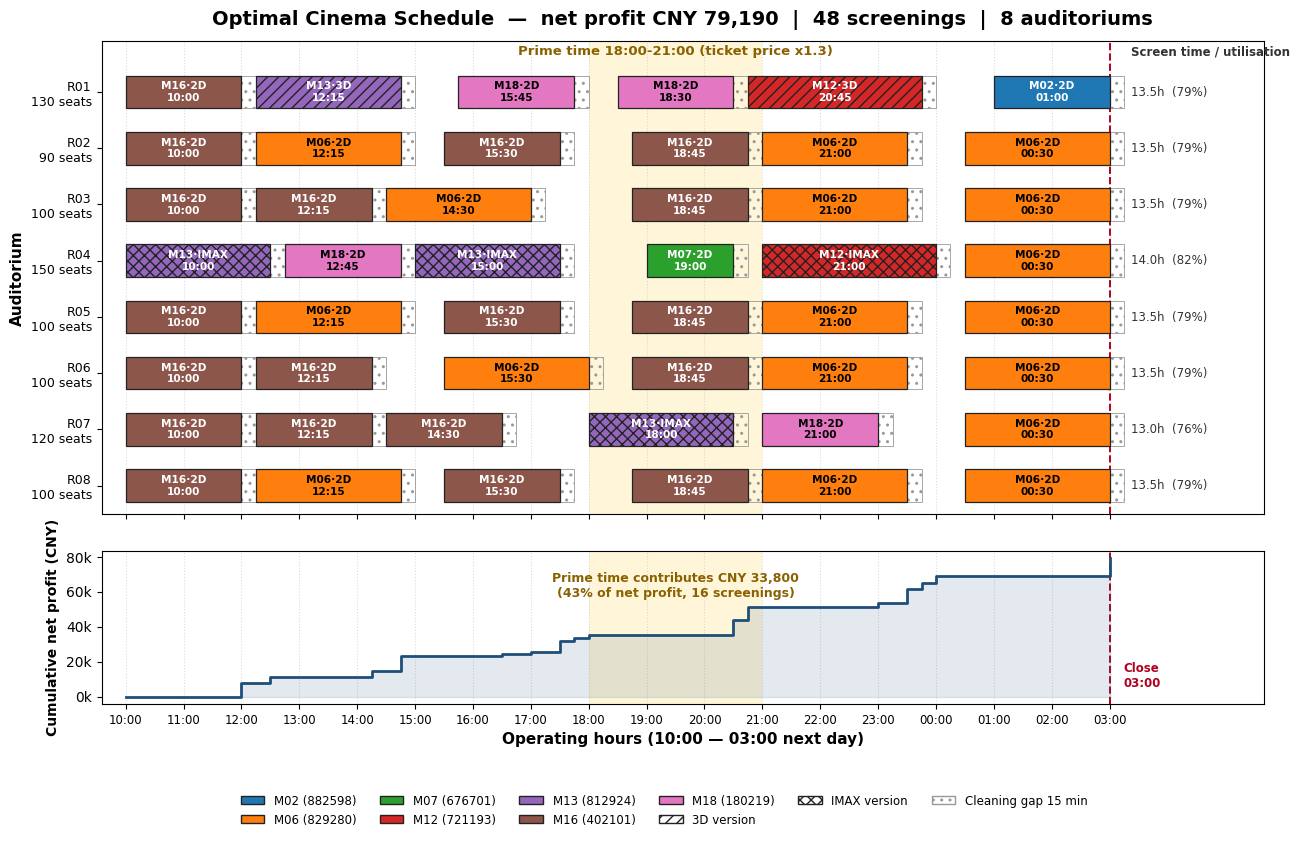

In [33]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams["axes.unicode_minus"] = False

PRIME_L, PRIME_R = min(prime_time), max(prime_time)

short_name = {m["id"]: f"M{i + 1:02d}" for i, m in enumerate(movie_data)}

used_movies = sorted({p["id"] for p in results}, key=lambda m: short_name[m])
palette = plt.get_cmap("tab20").colors
color_map = {m: palette[(2 * i) % 20] for i, m in enumerate(used_movies)}
hatch_map = {"2D": "", "3D": "///", "IMAX": "xxx"}
ypos = {r: i for i, r in enumerate(rooms)}

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(15, 8.6), sharex=True,
    gridspec_kw=dict(height_ratios=[3.1, 1], hspace=0.12))

for a in (ax, ax2):
    a.axvspan(PRIME_L, PRIME_R, color="#FFD24A", alpha=0.20, lw=0, zorder=0)
    a.axvline(CLOSE_MIN, color="#B00020", ls="--", lw=1.4, zorder=1)
    a.grid(axis="x", ls=":", alpha=0.45)
    a.set_axisbelow(True)
ax.text((PRIME_L + PRIME_R) / 2, -0.72,
        f"Prime time {minutes_to_time(PRIME_L)}-{minutes_to_time(PRIME_R)} "
        f"(ticket price x{prime_coeff})",
        ha="center", va="center", fontsize=9.5, color="#8A6100", fontweight="bold")

# ---------- Gantt bars ----------
for p in results:
    y, t, dur = ypos[p["room"]], p["start"], p["runtime"]
    c = color_map[p["id"]]
    ax.barh(y, dur, left=t, height=0.58, zorder=3, color=c,
            edgecolor="#222", linewidth=0.9, hatch=hatch_map[p["version"]])
    # 15-minute cleaning / turnaround block
    ax.barh(y, min_gap, left=t + dur, height=0.58, zorder=2,
            color="none", edgecolor="#999", linewidth=0.6, hatch="..")
    luminance = 0.299 * c[0] + 0.587 * c[1] + 0.114 * c[2]
    if dur >= 85:   # skip the label on narrow bars so text never overflows
        ax.text(t + dur / 2, y, f"{short_name[p['id']]}·{p['version']}\n{p['start_hhmm']}",
                ha="center", va="center", fontsize=7.6, zorder=4, fontweight="bold",
                color="black" if luminance > 0.5 else "white")

# ---------- Per-auditorium utilisation in the right margin ----------
for r in rooms:
    used = sum(p["runtime"] for p in results if p["room"] == r)
    ax.text(CLOSE_MIN + 22, ypos[r], f"{used / 60:.1f}h  ({used / CLOSE_MIN:.0%})",
            va="center", fontsize=8.5, color="#333")
ax.text(CLOSE_MIN + 22, -0.72, "Screen time / utilisation", fontsize=8.5,
        color="#333", fontweight="bold", va="center")

ax.set_yticks(range(len(rooms)))
ax.set_yticklabels([f"{r}\n{capacity[r]} seats" for r in rooms], fontsize=9)
ax.invert_yaxis()                       # R01 on top, matching the results table
ax.set_ylim(len(rooms) - 0.5, -0.9)
ax.set_ylabel("Auditorium", fontsize=11, fontweight="bold")
ax.set_title(f"Optimal Cinema Schedule  —  net profit CNY {model.objval:,.0f}  |  "
             f"{len(results)} screenings  |  {len(rooms)} auditoriums",
             fontsize=14, fontweight="bold", pad=12)

legend = [Patch(fc=color_map[m], ec="#222", label=f"{short_name[m]} ({m})")
          for m in used_movies]
legend += [Patch(fc="white", ec="#222", hatch=h, label=f"{v} version")
           for v, h in hatch_map.items() if h]
legend += [Patch(fc="none", ec="#999", hatch="..",
                 label=f"Cleaning gap {min_gap} min")]
fig.legend(handles=legend, ncol=6, fontsize=8.5, loc="lower center",
           bbox_to_anchor=(0.5, -0.045), frameon=False)

# ---------- Lower panel: cumulative net profit (accumulated at screening end) ----------
cx, cy, running = [OPEN_MIN], [0], 0
for p in sorted(results, key=lambda d: d["end"]):
    running += p["net"]
    cx.append(p["end"])
    cy.append(running)
ax2.step(cx, cy, where="post", color="#1f4e79", lw=2, zorder=3)
ax2.fill_between(cx, cy, step="post", color="#1f4e79", alpha=0.12, zorder=2)

net_prime = sum(p["net"] for p in results if p["is_prime"])
ax2.annotate(f"Prime time contributes CNY {net_prime:,.0f}\n"
             f"({net_prime / running:.0%} of net profit, "
             f"{sum(p['is_prime'] for p in results)} screenings)",
             xy=((PRIME_L + PRIME_R) / 2, running * 0.72), ha="center",
             fontsize=9, color="#8A6100", fontweight="bold")
ax2.set_ylabel("Cumulative net profit (CNY)", fontsize=10, fontweight="bold")
ax2.yaxis.set_major_formatter(lambda v, _: f"{v / 1000:.0f}k")

# ---------- Shared wall-clock x axis ----------
ticks = list(range(OPEN_MIN, CLOSE_MIN + 1, 60))
ax2.set_xticks(ticks)
ax2.set_xticklabels([minutes_to_time(t) for t in ticks], fontsize=8.5)
ax2.set_xlim(OPEN_MIN - 25, CLOSE_MIN + 160)
ax2.set_xlabel("Operating hours (10:00 — 03:00 next day)",
               fontsize=11, fontweight="bold")
ax2.text(CLOSE_MIN + 14, running * 0.15, "Close\n03:00",
         color="#B00020", fontsize=8.5, va="center", ha="left", fontweight="bold")

plt.savefig("movie_schedule_gantt.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()